# PFS x DESI Multi-Tracer Fisher Forecast --- Figures

This notebook reproduces all figures from the paper and lets you
tweak styling interactively.

**Three analysis scenarios:**
- **Broad**: conservative Gaussian priors (Chudaykin+ 2025)
- **Cross-cal**: priors calibrated from the PFS--DESI overlap (kmax = 0.20 h/Mpc)
- **Fixed nuisance**: nuisance parameters perfectly known (theoretical ceiling)

**SBP benchmark lines:**
- **SBP, PS**: power-spectrum-level simulation-based prior (Zhang+ 2025)
- **SBP, FL**: field-level simulation-based prior (Chudaykin+ 2026)

**Key parameters:**
- `f_shared = 0.045` (J. Shi, priv. comm.): shared ELG fraction between PFS and DESI
- `r_sigma_v = 0.75`: FoG velocity ratio sigma_v,PFS / sigma_v,DESI
- Asymmetric kmax in overlap: kmax_PFS = kmax_DESI / r_sigma_v

In [1]:
import os, sys
os.chdir("/Users/nguyenmn/PFSxDESI-multi-fish")
sys.path.insert(0, ".")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Run the pipeline (~30s)
from pfsfog.config import ForecastConfig
from pfsfog.cli import run_pipeline

cfg = ForecastConfig.from_yaml("configs/default.yaml")
results = run_pipeline(cfg, verbose=True)

Output → results/20260422_123720

=== Step 1: Overlap calibration ===
  Asymmetric kmax: DESI=0.200, PFS=0.267, cross=0.267 h/Mpc
  k_low: 39 bins to 0.200, k_high: 13 bins to 0.265
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that you are loading a non-standard model from the cosmopower-organization repo.
Falling back to the dictionary, in case this also fails or does not output the right shape make sure you ran the `convert_tf214.py` script, and that a `.npz` file exists among the trained models, and that you ran `pip install .`. Also make sure that you are asking for the right probe between `custom_log` and `custom_pca`.
Tried to load pickle file from pre-trained model, but failed.
This usually means that you have TF>=2.14, or that you are loading a model that was trained on PCA but loaded with the log (or viceversa), or that 

In [16]:
from pfsfog.plots import set_style
set_style()

# Convenient references
overlap = results.overlap_results        # {(zlo,zhi): OverlapResult}
scenarios = results.scenario_results      # {"broad": ScenarioResult, ...}
z_bins = results.config.z_bins

from pfsfog.eft_params import broad_priors, NUISANCE_NAMES, HOD_BENCHMARK, FIELD_LEVEL_BENCHMARK
from pfsfog.scenarios import SCENARIOS, compute_calibration_efficiency

COLORS = {"broad": "C0", "cross-cal": "C2", "oracle": "C1"}
LABELS = {"broad": "Broad", "cross-cal": "Cross-cal", "oracle": "Fixed nuis."}
scenario_names = [s.name for s in SCENARIOS]
cosmo_params = ["fsigma8", "Mnu", "Omegam"]

## Figure 1 --- Calibrated vs broad priors

Broad prior widths (bars) vs cross-calibrated widths (dots per z-bin)
for all DESI nuisance parameters. Parameters whose dots sit well below
the bar are substantially tightened (P_shot, bG2).

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


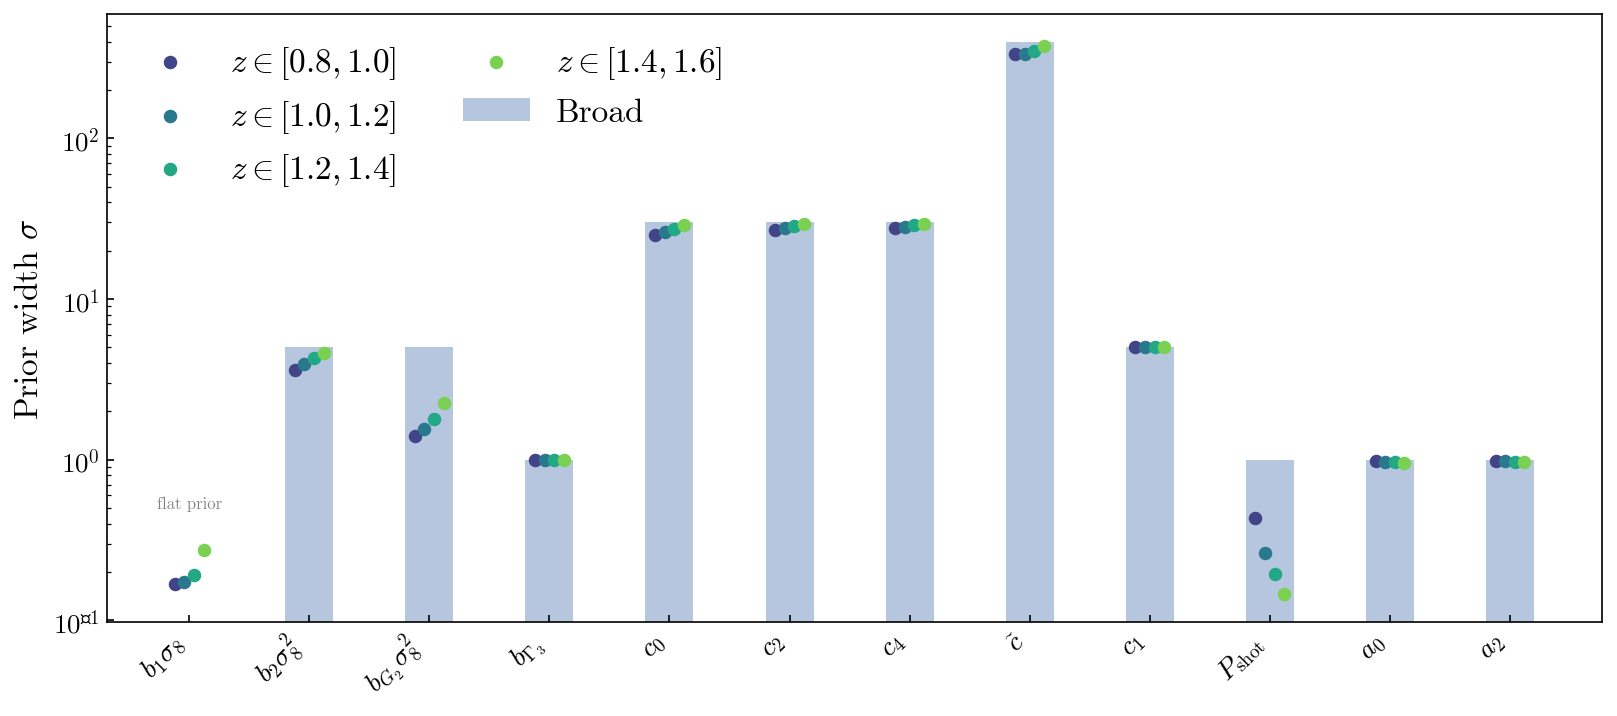

In [26]:
bp_dict = broad_priors().sigma_dict()
params_to_show = list(NUISANCE_NAMES)
plabels = {
    "b1_sigma8": r"$b_1\sigma_8$",
    "b2_sigma8sq": r"$b_2\sigma_8^2$", "bG2_sigma8sq": r"$b_{G_2}\sigma_8^2$",
    "bGamma3": r"$b_{\Gamma_3}$", "c0": r"$c_0$", "c2": r"$c_2$", "c4": r"$c_4$",
    "c_tilde": r"$\tilde{c}$", "c1": r"$c_1$",
    "Pshot": r"$P_{\rm shot}$", "a0": r"$a_0$", "a2": r"$a_2$",
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(params_to_show))

# Broad priors as bars (skip b1_sigma8 which has flat prior)
for i, p in enumerate(params_to_show):
    bv = bp_dict[p]
    if bv is not None:
        ax.bar(i, bv, 0.4, color="#4C72B0", alpha=0.4,
               label="Broad" if i == 1 else None)

# Calibrated priors per z-bin
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_zbins)))
for iz, zb in enumerate(sorted_zbins):
    cal = overlap[zb].calibrated_priors
    cal_vals = [cal.params.get(p, np.nan) for p in params_to_show]
    offset = (iz - len(sorted_zbins) / 2 + 0.5) * 0.08
    ax.scatter(x + offset, cal_vals, color=colors[iz], s=30, zorder=5,
               label=f"$z \\in [{zb[0]:.1f},{zb[1]:.1f}]$")

ax.set_xticks(x)
ax.set_xticklabels([plabels.get(p, p) for p in params_to_show],
                    rotation=45, ha="right")
ax.set_ylabel(r"Prior width $\sigma$")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=16, ncol=2)

# Annotate b1_sigma8 as flat prior
b1_idx = params_to_show.index("b1_sigma8")
ax.annotate("flat prior", xy=(b1_idx, 0.5), fontsize=8, ha="center",
            color="gray", style="normal")

fig.tight_layout()
plt.show()

## Figure 2 --- Full-area DESI constraints (money figure)

Bar chart of marginalized sigma(fsigma8), sigma(Mnu), sigma(Omegam)
under three scenarios. SBP benchmark lines from Zhang+ 2025 (PS-level)
and Chudaykin+ 2026 (field-level). No field-level line for Mnu because
SBPs worsen the LCDM bound (Chudaykin+ 2026, Table IV).

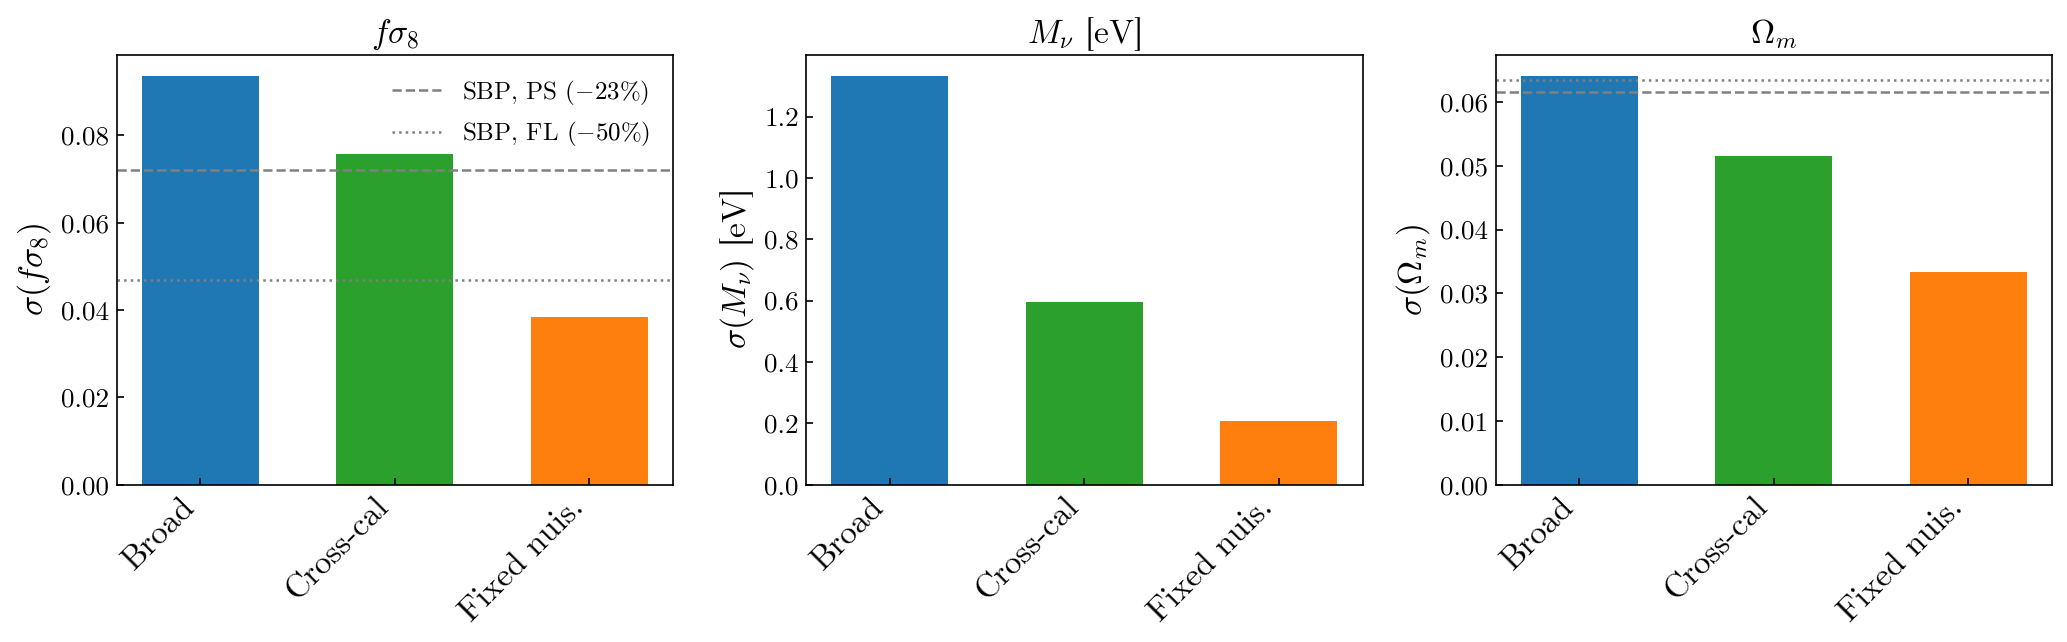


Headline numbers:
  Broad            $f\sigma_8$ : sigma = 9.3665e-02  (+0.0%)
  Broad            $M_\nu$ [eV]: sigma = 1.3325e+00  (+0.0%)
  Broad            $\Omega_m$  : sigma = 6.4089e-02  (+0.0%)
  Cross-cal        $f\sigma_8$ : sigma = 7.5864e-02  (+19.0%)
  Cross-cal        $M_\nu$ [eV]: sigma = 5.9614e-01  (+55.3%)
  Cross-cal        $\Omega_m$  : sigma = 5.1524e-02  (+19.6%)
  Fixed nuis.      $f\sigma_8$ : sigma = 3.8470e-02  (+58.9%)
  Fixed nuis.      $M_\nu$ [eV]: sigma = 2.0857e-01  (+84.3%)
  Fixed nuis.      $\Omega_m$  : sigma = 3.3417e-02  (+47.9%)


In [30]:
param_titles = [r"$f\sigma_8$", r"$M_\nu$ [eV]", r"$\Omega_m$"]
param_ylabels = [r"$\sigma(f\sigma_8)$", r"$\sigma(M_\nu)$ [eV]", r"$\sigma(\Omega_m)$"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ip, (cp, title, ylabel) in enumerate(zip(cosmo_params, param_titles, param_ylabels)):
    ax = axes[ip]
    x = np.arange(len(scenario_names))
    vals = [scenarios[sn].sigmas_combined[cp] for sn in scenario_names]
    colors = [COLORS[sn] for sn in scenario_names]

    ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[sn] for sn in scenario_names], rotation=45, ha="right", fontsize=16)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    sigma_broad = scenarios["broad"].sigmas_combined[cp]

    if cp == "fsigma8":
        hod_imp = HOD_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray",
                   lw=1.2, label=fr"SBP, PS ($-{hod_imp*100:.0f}$%)")
        fl_imp = FIELD_LEVEL_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray",
                   lw=1.2, label=fr"SBP, FL ($-{fl_imp*100:.0f}$%)")
        ax.legend(frameon=False, loc="upper right")

    if cp == "Omegam":
        hod_imp = HOD_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray", lw=1.2)
        fl_imp = FIELD_LEVEL_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray", lw=1.2)

fig.tight_layout()
plt.show()

# Print headline numbers
print("\nHeadline numbers:")
sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}
for sn in scenario_names:
    for cp, label in zip(cosmo_params, param_titles):
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        print(f"  {LABELS[sn]:16s} {label:12s}: sigma = {s:.4e}  ({imp:+.1f}%)")

## Figure 3 --- Calibration efficiency per z-bin

Efficiency = (sigma_broad - sigma_xcal) / (sigma_broad - sigma_fixed).
0 = cross-cal adds nothing; 1 = achieves the fixed-nuisance limit.

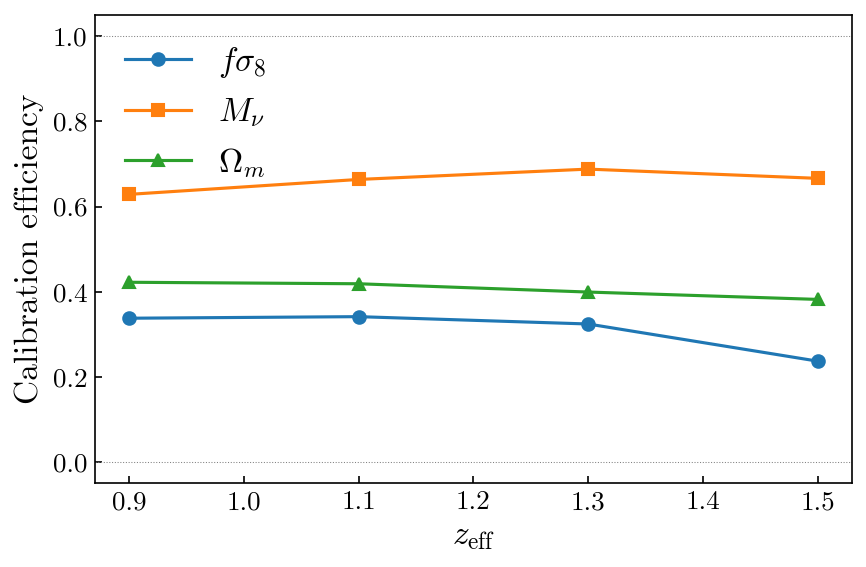

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

markers = {"fsigma8": "o", "Mnu": "s", "Omegam": "^"}
clabels = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}
z_mids = [0.5 * (zb[0] + zb[1]) for zb in z_bins]

for cp in cosmo_params:
    effs = []
    for zb in z_bins:
        sb = scenarios["broad"].sigmas_per_z[zb][cp]
        so = scenarios["oracle"].sigmas_per_z[zb][cp]
        sx = scenarios["cross-cal"].sigmas_per_z[zb][cp]
        eff = compute_calibration_efficiency(sx, sb, so)
        effs.append(eff if eff is not None else 0.0)
    ax.plot(z_mids, effs, marker=markers[cp], label=clabels[cp], lw=1.5)

ax.set_xlabel(r"$z_{\rm eff}$")
ax.set_ylabel("Calibration efficiency")
ax.set_ylim(-0.05, 1.05)
ax.axhline(1.0, ls=":", color="gray", lw=0.5)
ax.axhline(0.0, ls=":", color="gray", lw=0.5)
ax.legend(frameon=False, fontsize=16)
fig.tight_layout()
plt.show()

## Figure 4 --- Sensitivity to r_sigma_v (two curves)

Two curves disentangle the r_sigma_v channels:
- **Asymmetric kmax** (green): kmax_PFS = kmax_DESI / r_sigma_v (default)
- **Symmetric kmax** (red): kmax_PFS = kmax_DESI = 0.20 (fixed)

The gap between the red curve and the broad baseline = gain from
multi-tracer stochastic/bias separation (independent of r_sigma_v).
The gap between green and red = additional gain from asymmetric kmax.

**This cell re-runs the pipeline for each r_sigma_v value (~30s each, ~5 min total).**

  r_sv=0.50: asym=7.2100e-02 (+23.0%)  sym=7.7356e-02 (+17.4%)
  r_sv=0.60: asym=7.3620e-02 (+21.4%)  sym=7.7353e-02 (+17.4%)
  r_sv=0.75: asym=7.5864e-02 (+19.0%)  sym=7.7342e-02 (+17.4%)
  r_sv=0.90: asym=7.6976e-02 (+17.8%)  sym=7.7321e-02 (+17.4%)
  r_sv=1.00: asym=7.7296e-02 (+17.5%)  sym=7.7296e-02 (+17.5%)


TypeError: 'int' object is not iterable

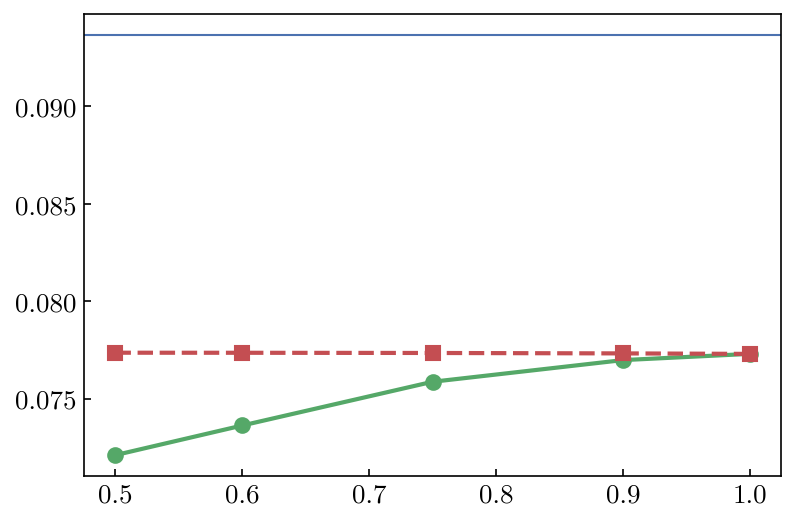

In [10]:
r_values = [0.5, 0.6, 0.75, 0.9, 1.0]
sigma_asym = {}
sigma_sym = {}
broad_baseline = None

for r in r_values:
    # Asymmetric kmax (default)
    cfg_r = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv")
    res_r = run_pipeline(cfg_r, verbose=False)
    sigma_asym[r] = res_r.scenario_results["cross-cal"].sigmas_combined["fsigma8"]
    if broad_baseline is None:
        broad_baseline = res_r.scenario_results["broad"].sigmas_combined["fsigma8"]

    # Symmetric kmax (fixed kmax_PFS = kmax_DESI)
    cfg_s = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv",
                           kmax_pfs_overlap=0.20, kmax_cross_overlap=0.20)
    res_s = run_pipeline(cfg_s, verbose=False)
    sigma_sym[r] = res_s.scenario_results["cross-cal"].sigmas_combined["fsigma8"]

    imp_a = (broad_baseline - sigma_asym[r]) / broad_baseline * 100
    imp_s = (broad_baseline - sigma_sym[r]) / broad_baseline * 100
    print(f"  r_sv={r:.2f}: asym={sigma_asym[r]:.4e} ({imp_a:+.1f}%)  "
          f"sym={sigma_sym[r]:.4e} ({imp_s:+.1f}%)")

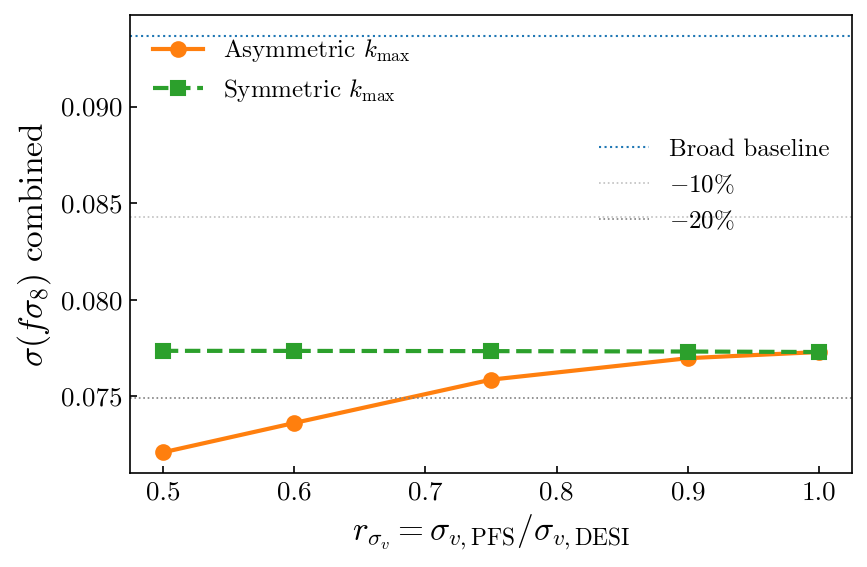

In [37]:
fig, ax = plt.subplots(figsize=(6, 4))

r_arr = sorted(sigma_asym.keys())
h1, = ax.plot(r_arr, [sigma_asym[r] for r in r_arr], "o-", color="C1",
              lw=2, ms=7, label=r"Asymmetric $k_{\max}$")
h2, = ax.plot(r_arr, [sigma_sym[r] for r in r_arr], "s--", color="C2",
              lw=2, ms=7, label=r"Symmetric $k_{\max}$")

h3 = ax.axhline(broad_baseline, ls=":", color="C0", lw=1, label="Broad baseline")
c = ['silver', 'gray']
h4 = ax.axhline(broad_baseline * 0.9, ls=':', color=c[0], lw=0.8, label=r"$-10$%")
h5 = ax.axhline(broad_baseline * 0.8, ls=':', color=c[1], lw=0.8, label=r"$-20$%")

ax.set_xlabel(r"$r_{\sigma_v} = \sigma_{v,\mathrm{PFS}} / \sigma_{v,\mathrm{DESI}}$")
ax.set_ylabel(r"$\sigma(f\sigma_8)$ combined")

leg1 = ax.legend(
    [h1, h2],
    [r"Asymmetric $k_{\max}$", r"Symmetric $k_{\max}$"],
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(0., 1.00),
)

ax.add_artist(leg1)

leg2 = ax.legend(
    [h3, h4, h5],
    ["Broad baseline", r"$-10$%", r"$-20$%"],
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.00, 0.78),
)

fig.tight_layout()
plt.show()

## Summary table

In [8]:
print(f"{'Scenario':<18s} {'kmax':>5s}  {'sigma(fs8)':>10s}  {'D%':>6s}  "
      f"{'sigma(Mnu)':>10s}  {'D%':>6s}  {'sigma(Om)':>10s}  {'D%':>6s}")
print("-" * 85)

sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}

for sn in scenario_names:
    sc = [s for s in SCENARIOS if s.name == sn][0]
    row = f"{LABELS[sn]:<18s} {sc.kmax:5.2f}"
    for cp in cosmo_params:
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        row += f"  {s:10.4e}  {imp:+5.1f}%"
    print(row)

print()
print(f"kmax_DESI = {cfg.kmax_desi_overlap:.3f}, "
      f"kmax_PFS = {cfg.compute_kmax_pfs():.3f} h/Mpc  "
      f"(r_sv = {cfg.r_sigma_v})")
print(f"f_shared = {cfg.f_shared_elg}")
print(f"Overlap: {cfg.overlap_area_deg2:.0f} deg^2, "
      f"Full DESI: {cfg.desi_area_deg2:.0f} deg^2")
print(f"z-bins: {z_bins}")

Scenario            kmax  sigma(fs8)      D%  sigma(Mnu)      D%   sigma(Om)      D%
-------------------------------------------------------------------------------------
Broad               0.20  9.3665e-02   +0.0%  1.3325e+00   +0.0%  6.4089e-02   +0.0%
Cross-cal           0.20  7.5864e-02  +19.0%  5.9614e-01  +55.3%  5.1524e-02  +19.6%
Fixed nuis.         0.20  3.8470e-02  +58.9%  2.0857e-01  +84.3%  3.3417e-02  +47.9%

kmax_DESI = 0.200, kmax_PFS = 0.267 h/Mpc  (r_sv = 0.75)
f_shared = 0.045
Overlap: 1200 deg^2, Full DESI: 14000 deg^2
z-bins: [(0.8, 1.0), (1.0, 1.2), (1.2, 1.4), (1.4, 1.6)]
